### Attribution with TorchCAM

In [301]:
from torchvision.io import decode_image
from torchvision.models import get_model, get_model_weights
from torchcam.methods import LayerCAM

import matplotlib.pyplot as plt

from torchvision.transforms.v2.functional import to_pil_image
from torchcam.utils import overlay_mask

import pandas as pd



In [302]:
def Preprocess(model, preprocess, image_path, target_class=None):

    img = decode_image(image_path)
    input_tensor = preprocess(img)

    with LayerCAM(model) as cam_extractor:
        out = model(input_tensor.unsqueeze(0))
        if target_class is None:
            target_class = out.squeeze(0).argmax().item()
        activation_map = cam_extractor(target_class, out)
    return img, out, activation_map

In [303]:
def ShowActivationMap(activation_map):
    plt.imshow(activation_map[0].squeeze(0).numpy())
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [304]:
def ShowOverlayMask(img, activation_map):
    result = overlay_mask(to_pil_image(img), to_pil_image(activation_map[0].squeeze(0), mode='F'), alpha=0.5)
    plt.imshow(result)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [305]:
#> claude.ai
#> I have a json file with class names (imagenet_class_index.json) from 1000 classes in ImageNet and an output 
#  tensor from a ResNet18 (with default pretrained weights) softmax operation. 
#  Give a function that maps the maximum logit in the output tensor to the class name from the json file.

import json
import torch

def predict_class(output_tensor: torch.Tensor, class_index_path: str) -> dict:
    """
    Maps the maximum logit in a softmax output tensor to an ImageNet class name.

    Args:
        output_tensor:    1D or 2D tensor of shape (1000,) or (1, 1000),
                          typically the output of a softmax layer from ResNet18.
        class_index_path: Path to the imagenet_class_index.json file.

    Returns:
        A dict with keys:
            - 'class_index'  (int)   : index of the predicted class (0–999)
            - 'class_id'     (str)   : WordNet synset ID, e.g. "n01440764"
            - 'class_name'   (str)   : human-readable label, e.g. "tench"
            - 'confidence'   (float) : softmax probability of the top class
    """
    with open(class_index_path, "r") as f:
        class_index = json.load(f)  # keys are str "0".."999"

    # Flatten to 1-D in case the tensor has a batch dimension
    probs = output_tensor.squeeze()          # (1000,)
    if probs.ndim != 1 or probs.shape[0] != 1000:
        raise ValueError(
            f"Expected a tensor of 1000 values, got shape {tuple(output_tensor.shape)}"
        )

    #top_idx = int(probs.argmax())            # index of highest probability
    

    top5 = torch.topk(probs, 5)
    return_list =[]
    
    for index in top5.indices:
        index = int(index)
        synset_id, class_name = class_index[str(index)]
        return_list.append({
            "class_index": index,
            "class_id":    synset_id,
            "class_name":  class_name,
            "confidence":  round(float(probs[index]),6)
            })
    df = pd.DataFrame(return_list)

    return df

In [306]:
def ImageClassificator(model, preprocess, image_path, target_class):
    img, out, activation_map = Preprocess(model, preprocess, image_path, target_class)
    ShowActivationMap(activation_map)
    ShowOverlayMask(img, activation_map)

    prediction = out.squeeze(0).softmax(0)
    print(predict_class(prediction.detach(), "data/imagenet_class_index.json"))

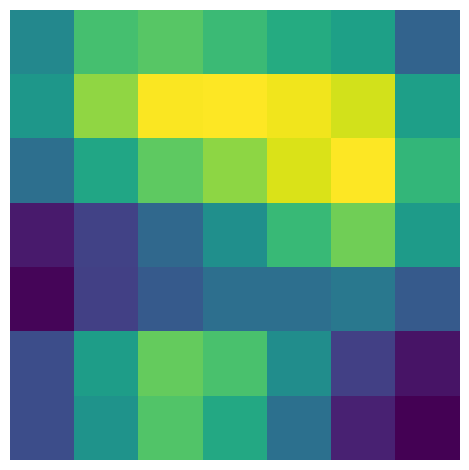

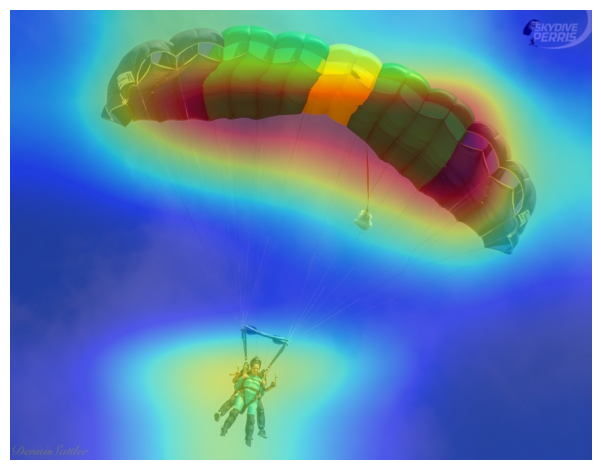

   class_index   class_id class_name  confidence
0          701  n03888257  parachute    0.999966
1          417  n02782093    balloon    0.000033
2          879  n04507155   umbrella    0.000001
3          557  n03355925   flagpole    0.000001
4          405  n02692877    airship    0.000000


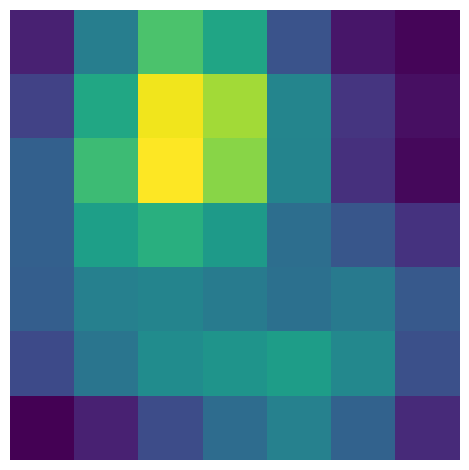

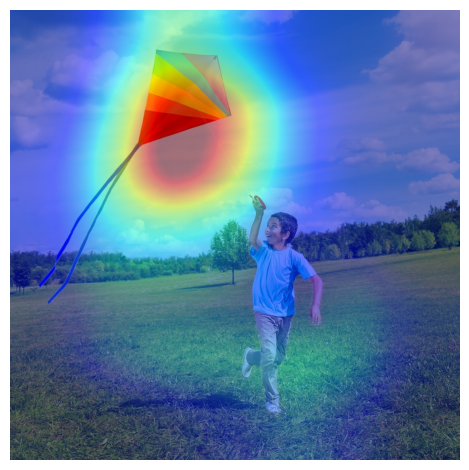

   class_index   class_id   class_name  confidence
0          701  n03888257    parachute    0.598860
1          879  n04507155     umbrella    0.103751
2          984  n11879895     rapeseed    0.062746
3          723  n03944341     pinwheel    0.024724
4          805  n04254680  soccer_ball    0.023913


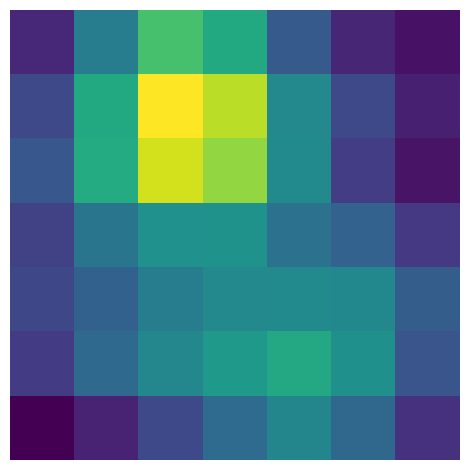

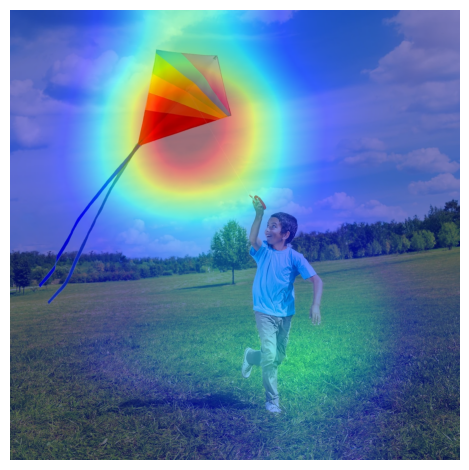

   class_index   class_id   class_name  confidence
0          701  n03888257    parachute    0.598860
1          879  n04507155     umbrella    0.103751
2          984  n11879895     rapeseed    0.062746
3          723  n03944341     pinwheel    0.024724
4          805  n04254680  soccer_ball    0.023913


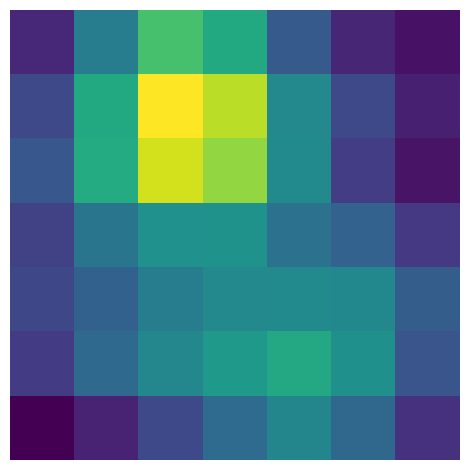

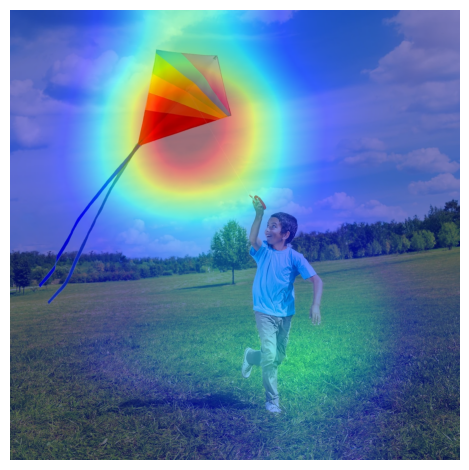

   class_index   class_id   class_name  confidence
0          701  n03888257    parachute    0.598860
1          879  n04507155     umbrella    0.103751
2          984  n11879895     rapeseed    0.062746
3          723  n03944341     pinwheel    0.024724
4          805  n04254680  soccer_ball    0.023913


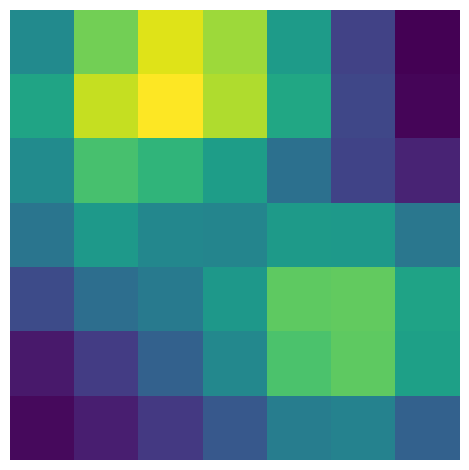

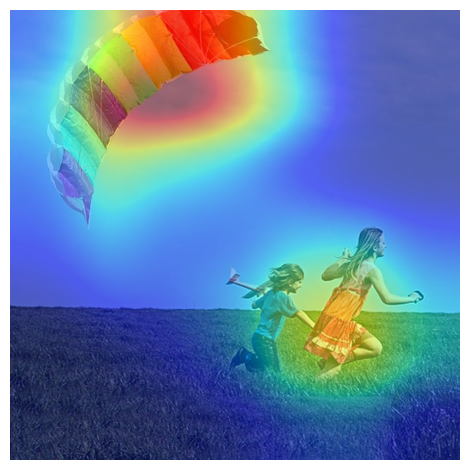

   class_index   class_id class_name  confidence
0          701  n03888257  parachute    0.998736
1          723  n03944341   pinwheel    0.000445
2          417  n02782093    balloon    0.000278
3          645  n03733131    maypole    0.000220
4          879  n04507155   umbrella    0.000107


In [313]:
weights = get_model_weights("resnet18").DEFAULT
model = get_model("resnet18", weights=weights).eval()
preprocess = weights.transforms()


image_path = "data/parachute.jpg"
target_class = 701 # parachute 
ImageClassificator(model, preprocess, image_path, target_class)

image_path = "data/kite.webp"
target_class = None
ImageClassificator(model, preprocess, image_path, target_class)

image_path = "data/kite.webp"
target_class = 417  #baloon 
ImageClassificator(model, preprocess, image_path, target_class)

image_path = "data/kite.webp"
target_class = 417  #baloon 
ImageClassificator(model, preprocess, image_path, target_class)


image_path = "data/kiteparachute.jpg"
target_class = 417  #baloon 
ImageClassificator(model, preprocess, image_path, target_class)
